# Q8: Results

**Phase 9:** Results & Insights  
**Points: 3 points**

**Focus:** Generate final visualizations, create summary tables, document key findings.

**Lecture Reference:** Lecture 11, Notebook 4 ([`11/demo/04_modeling_results.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/04_modeling_results.ipynb)), Phase 9. Also see Lecture 07 (visualization).

---

## Setup

In [57]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load model results from Q7
predictions = pd.read_csv('output/q7_predictions.csv')
metrics = open('output/q7_model_metrics.txt').read()
feature_importance = pd.read_csv('output/q7_feature_importance.csv')

---

## Objective

Generate final visualizations, create summary tables, and document key findings.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q8_final_visualizations.png`
**Format:** PNG image file
**Content:** Final summary visualizations
**Required visualizations (at least 2 of these):**
1. **Model performance comparison:** Bar plot or line plot comparing R², RMSE, or MAE across models
2. **Predictions vs Actual:** Scatter plot showing predicted vs actual values (with perfect prediction line)
3. **Feature importance:** Bar plot showing top N features by importance
4. **Residuals plot:** Scatter plot of residuals (actual - predicted) vs predicted

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 2. `output/q8_summary.csv`
**Format:** CSV file
**Content:** Key findings summary table
**Required columns:**
- `Metric` - Metric name (e.g., "R² Score", "RMSE", "MAE")
- One column per model (e.g., `Linear Regression`, `Random Forest`, `XGBoost`)

**Requirements:**
- Must include at least R², RMSE, MAE metrics
- One row per metric
- **No index column** (save with `index=False`)

**Example:**
```csv
Metric,Linear Regression,Random Forest,XGBoost
R² Score,-0.0201,0.9705,0.9967
RMSE,12.7154,2.1634,0.7276
MAE,9.8468,1.3545,0.4480
```

### 3. `output/q8_key_findings.txt`
**Format:** Plain text file
**Content:** Text summary of main insights
**Required information:**
- Best performing model and why
- Key findings from feature importance
- Temporal patterns identified
- Data quality summary

**Example format:**
```
KEY FINDINGS SUMMARY
===================

MODEL PERFORMANCE:
- Best performing model: XGBoost (R² = 0.9967)
- All models show reasonable performance (R² > 0.7 for tree-based models)
- XGBoost achieves lowest RMSE: 0.73°C

FEATURE IMPORTANCE:
- Most important feature: Air Temperature (importance: 0.6539)
- Top 3 features account for 93.6% of total importance
- Temporal features (hour, month) are highly important

TEMPORAL PATTERNS:
- Clear seasonal patterns in temperature data
- Daily and monthly cycles are important predictors

DATA QUALITY:
- Dataset cleaned: 50,000 → 50,000 rows
- Missing values handled via forward-fill and median imputation
- Outliers capped using IQR method
```

---

## Requirements Checklist

- [ ] Final visualizations created (model performance, key insights)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Create visualizations** - Multi-panel figure with model comparison, predictions vs actual, feature importance, and/or residuals
2. **Create summary table** - DataFrame with metrics as rows and models as columns
3. **Document key findings** - Text summary covering model performance, feature importance insights, temporal patterns, and data quality notes

---

## Decision Points

- **Visualizations:** What best communicates your findings? Model performance plots? Time series with predictions? Feature importance plots?
- **Summary:** What are the key takeaways? Document the most important findings from your analysis.

---

## Checkpoint

After Q8, you should have:
- [ ] Final visualizations created (2+ plots)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 artifacts saved: `q8_final_visualizations.png`, `q8_summary.csv`, `q8_key_findings.txt`

---

**Next:** Continue to `q9_writeup.md` for Writeup.


In [58]:
# I work on output/q8_final_visualizations.png

# first I inspect predictions df
predictions.head()

,actual,predicted_linear,predicted_rf
0,20.17,19.370073,21.662599
1,21.00,20.002706,21.817936
2,21.40,20.437582,21.391156
3,20.56,19.817798,21.280601
4,21.90,20.711598,22.085088


In [59]:
# now I generate MAE values for predicted_linear and predicted_rf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_linear = mean_absolute_error(predictions['actual'], predictions['predicted_linear'])
print(mse_linear)

mse_rf = mean_absolute_error(predictions['actual'], predictions['predicted_rf'])
print(mse_rf)

model_error_metrics = pd.DataFrame({"Model": ["Linear Regression", "Random Forest Regressor"], "Mean Absolute Error": [mse_linear, mse_rf]})

print(model_error_metrics)

5.17897371328277
3.743533196381735
                     Model  Mean Absolute Error
0        Linear Regression             5.178974
1  Random Forest Regressor             3.743533


In [60]:
# I will load in feature importances for Random Forest Regressor that I calculatd in previous question

feature_importance.head()

# I will inspect just the top 10 most valuable features for 

top_10_features = feature_importance.head(10)
print(top_10_features)

                           feature  importance
0                        Is Summer    0.445335
1                            month    0.386196
2      total_rain_rolling_mean_24h    0.051793
3  solar_radiation_rolling_mean_7h    0.028426
4                         Humidity    0.020582
5         humidity_rolling_mean_7h    0.018142
6                             year    0.016658
7                 Wind Direction Y    0.008298
8                      day_of_week    0.005968
9                  Solar Radiation    0.005634


In [61]:
# calculate residuals for both Linear Regression and Random Forest

residuals_linear = predictions['actual'] - predictions['predicted_linear']

print(residuals_linear)

residuals_rf = predictions['actual'] - predictions['predicted_rf']

print(residuals_rf)


0        0.799927
1        0.997294
2        0.962418
3        0.742202
4        1.188402
           ...   
39259   -8.542188
39260   -7.804618
39261   -8.472255
39262   -6.916444
39263   -7.271607
Length: 39264, dtype: float64
0       -1.492599
1       -0.817936
2        0.008844
3       -0.720601
4       -0.185088
           ...   
39259   -8.171458
39260   -8.553456
39261   -8.021875
39262   -8.283614
39263   -7.494219
Length: 39264, dtype: float64


/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to 

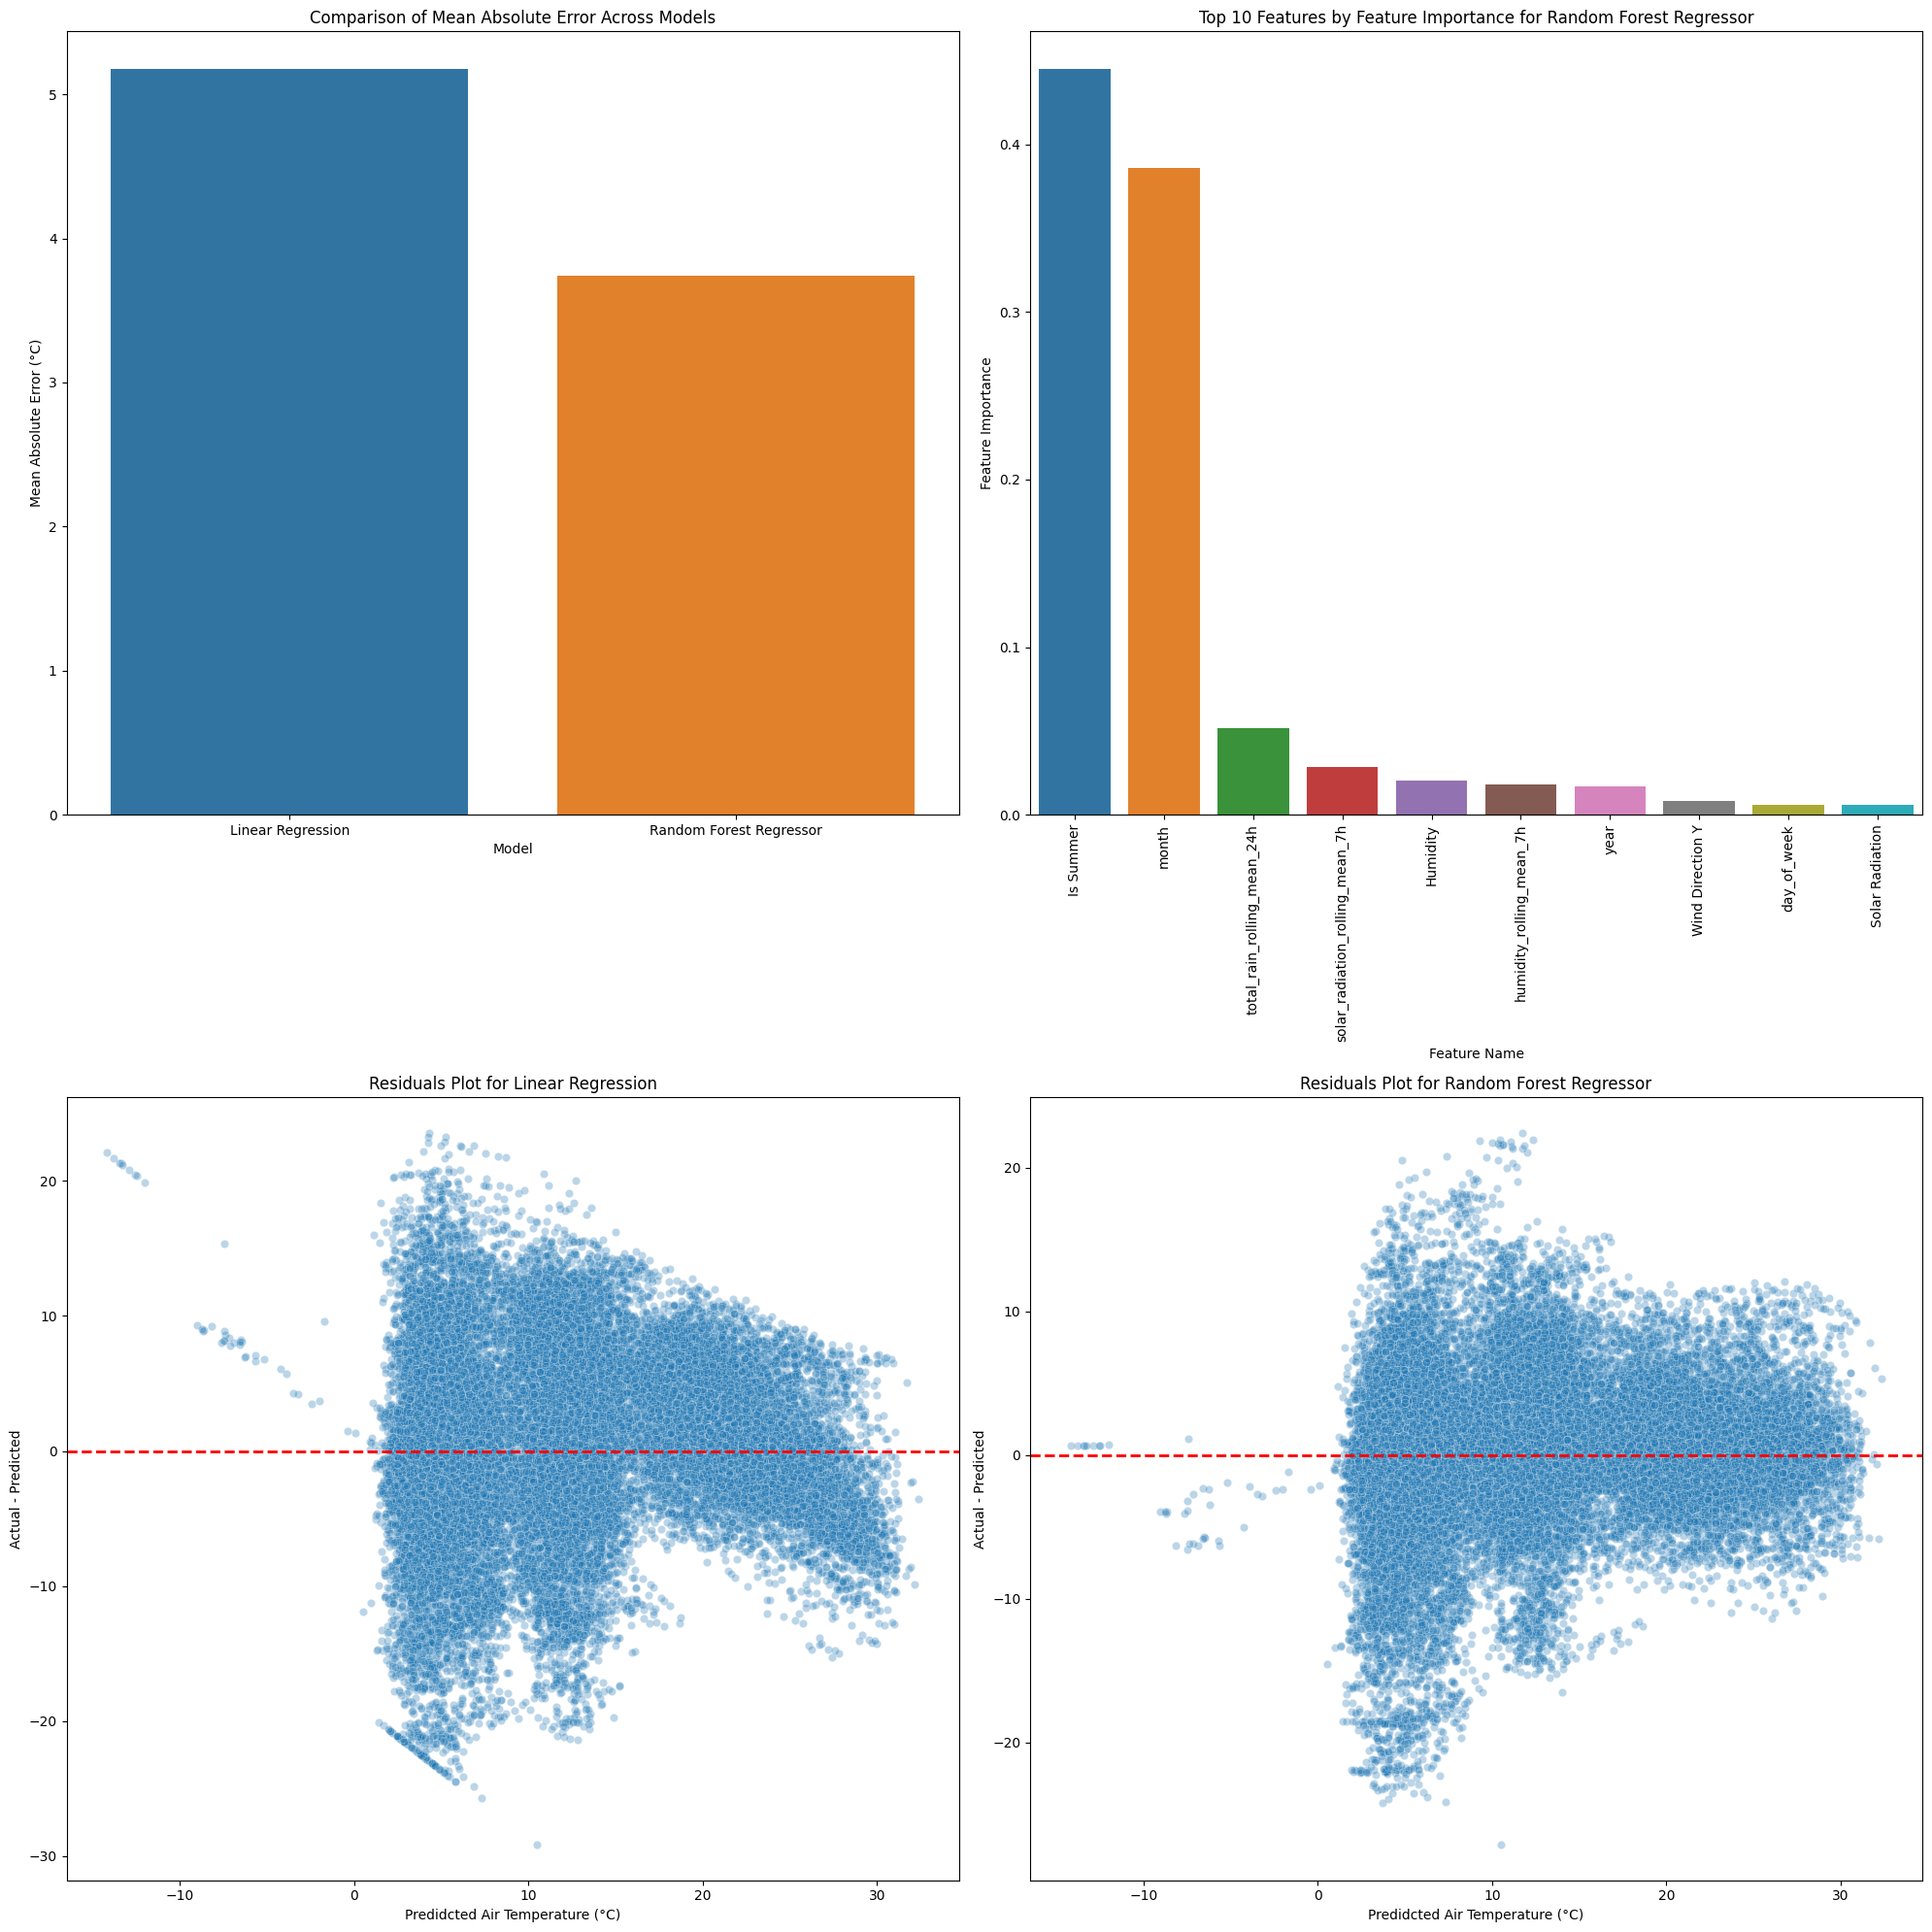

In [80]:
# now I will create the visualizations for output/q8_final_visualizations.png

fig, axes = plt.subplots(2, 2, figsize = (20,20))
sns.barplot(data = model_error_metrics, x = 'Model', y = 'Mean Absolute Error', ax = axes[0,0], hue='Model')
axes[0, 0].set_ylabel("Mean Absolute Error (°C)")
axes[0, 0].set_title("Comparison of Mean Absolute Error Across Models")
sns.barplot(data = top_10_features, x = "feature", y = "importance", ax = axes[0, 1], hue = 'feature')
axes[0, 1].tick_params(axis='x', rotation=90)
axes[0, 1].set_xlabel("Feature Name")
axes[0, 1].set_ylabel("Feature Importance")
axes[0, 1].set_title("Top 10 Features by Feature Importance for Random Forest Regressor")
sns.scatterplot(x = predictions["predicted_linear"], y = residuals_linear, alpha = 0.3, ax = axes[1, 0])
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2) 
axes[1, 0].set_xlabel("Predidcted Air Temperature (°C)")
axes[1, 0].set_ylabel("Actual - Predicted")
axes[1, 0].set_title("Residuals Plot for Linear Regression")
sns.scatterplot(x = predictions["predicted_linear"], y = residuals_rf, alpha = 0.3, ax = axes[1, 1])
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2) 
axes[1, 1].set_xlabel("Predidcted Air Temperature (°C)")
axes[1, 1].set_ylabel("Actual - Predicted")
axes[1, 1].set_title("Residuals Plot for Random Forest Regressor")

plt.tight_layout()
plt.savefig("output/q8_final_visualizations.png", dpi =300)

In [85]:
# output/q8_summary.csv

# create summary dataframe with error metrics for each model 

summary = pd.DataFrame({"Metric": ["R² Score", "RMSE", "MAE"], 
                        "Linear Regression": [r2_score(predictions['actual'], predictions['predicted_linear']),
                                              mean_squared_error(predictions['actual'], predictions['predicted_linear']),
                                              mean_absolute_error(predictions['actual'], predictions['predicted_linear'])],
                        "Random Forest Regressor": [r2_score(predictions['actual'], predictions['predicted_rf']),
                                                   mean_squared_error(predictions['actual'], predictions['predicted_rf']),
                                                   mean_absolute_error(predictions['actual'], predictions['predicted_rf'])]})

# turn summary dataframe into csv 
summary.to_csv("output/q8_summary.csv", index = False)

In [86]:
# take a look at summary dataframe
summary

,Metric,Linear Regression,Random Forest Regressor
0,R² Score,0.569533,0.736717
1,RMSE,44.140831,26.997480
2,MAE,5.178974,3.743533


In [102]:
# output/q8_key_findings.txt

# I generate report of key findings

with open('output/q8_key_findings.txt', 'w') as f:
    f.write('KEY FINDINGS SUMMARY:\n')
    f.write('MODEL PERFORMANCE:\n')
    f.write('- Best performing model: Random Forest Regresor (R² Score = 0.736717, RMSE = 26.997480, MAE = 3.743533)\n')
    f.write('- Random Forest Regressor outperforms Linear Regression for all three error metrics')
    f.write('- Random Forest Regressor achieves R² Score closer to 1, smaller RMSE, and smaller MAE\n')
    f.write('FEATURE IMPORTANCE:\n')
    f.write(f"- Most important feature: Is Summer (importance: {top_10_features['importance'][0]:.5f})\n")
    f.write(f"- Top 3 features account for {sum(top_10_features['importance'][0:2] * 100):.5f}% of total importance\n")
    f.write(f"- Features corresponding to/derivative of total rain, solar radiation, humidity, wind direction also have high feature importance")
    f.write(f"- Temporal features (Is Summer, month) are highly important\n")
    f.write("TEMPORAL PATTERNS:\n")
    f.write("- Air Temperature follows seasonal patterns\n")
    f.write("- important predictors are 'Is Summer', 'month', 'year', 'day_of_week'\n")
    f.write("- this demonstrates that Air Temperature follows seasonal, monthly, yearly, and daily cycles\n")
    f.write("DATA QUALITY:\n")
    f.write("- Dataset cleaned: 196313 rows --> 196313 rows\n")
    f.write("- Missing values handled via forward-fill\n")
    f.write("- Outliers capped using 3 z-Scores\n")